# Data Download, Preprocessing, and Exploratory Data Analysis

This notebook documents the initial stages of the stock return prediction pipeline:

1. raw data loading and inspection  
2. missing-value analysis  
3. preprocessing logic  
4. return construction  
5. train/test split overview  
6. initial exploratory analysis  

The goal is to establish a clean, reproducible data foundation before feature engineering and model development.

In [3]:
from pathlib import Path
import sys

# Go to project root
PROJECT_ROOT = Path.cwd()

# If notebook is inside notebooks/, this usually works:
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from src import config
from src.utils.paths import get_processed_returns_paths
from src.utils.plotting import (
    STYLE,
    AUX_COLORS,
    plot_multi_series,
)

In [5]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 50)

In [6]:
NOTEBOOK_NAME = "notebook01"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Reports dir :", REPORTS_DIR)
print("Tables dir  :", TABLES_DIR)
print("Figures dir :", FIGURES_DIR)

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> None:
    """
    Save a dataframe to the notebook's reporting tables folder.
    """
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")


def fig_path(filename: str) -> str:
    """
    Return a string path for saving figures from plotting helpers.
    """
    return str(FIGURES_DIR / filename)


Reports dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports
Tables dir  : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01
Figures dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook01


## 1. Research context

This project studies cross-sectional stock return prediction.  
The objective is to predict each stock's **next-month return** using information available at month-end.

The data pipeline uses:

- adjusted close prices for return construction
- OHLCV data for extended feature engineering
- a time-based train/test split to avoid leakage

This notebook focuses only on the **data and preprocessing layer**.

In [7]:
config_summary = pd.DataFrame(
    {
        "setting": [
            "n_tickers",
            "start_date",
            "end_date",
            "train_end_date",
            "test_start_date",
            "market_ticker",
            "use_log_returns",
            "top_percentage",
            "raw_adj_close_path",
            "raw_ohlcv_path",
        ],
        "value": [
            len(config.TICKERS),
            config.START_DATE,
            config.END_DATE,
            config.TRAIN_END_DATE,
            config.TEST_START_DATE,
            getattr(config, "MARKET_TICKER", None),
            getattr(config, "USE_LOG_RETURNS", None),
            getattr(config, "TOP_PERCENTAGE", None),
            getattr(config, "RAW_ADJ_CLOSE_PATH", None),
            getattr(config, "RAW_OHLCV_PATH", None),
        ],
    }
)
config_summary

,setting,value
0,n_tickers,100
1,start_date,2015-01-01
2,end_date,2025-12-31
3,train_end_date,2024-12-31
4,test_start_date,2025-01-01
5,market_ticker,None
6,use_log_returns,False
7,top_percentage,0.2
8,raw_adj_close_path,data/raw/adj_close_2015_2025.parquet
9,raw_ohlcv_path,data/raw/ohlcv_2015_2025.parquet


## 2. Raw data files

Use two raw data files:

- **Adjusted Close**: used to construct return series
- **OHLCV**: Open, High, Low, Close, Adjusted Close, and Volume, used for richer feature engineering

First inspect their basic structure.

In [8]:
adj_close_path = PROJECT_ROOT / config.RAW_ADJ_CLOSE_PATH
ohlcv_path = PROJECT_ROOT / config.RAW_OHLCV_PATH

print("Adjusted close path:", adj_close_path)
print("OHLCV path:", ohlcv_path)
print("Adjusted close exists:", adj_close_path.exists())
print("OHLCV exists:", ohlcv_path.exists())

adj_close = pd.read_parquet(adj_close_path)
ohlcv = pd.read_parquet(ohlcv_path)

adj_close.index = pd.to_datetime(adj_close.index)
adj_close = adj_close.sort_index()

ohlcv.index = pd.to_datetime(ohlcv.index)
ohlcv = ohlcv.sort_index()

Adjusted close path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\raw\adj_close_2015_2025.parquet
OHLCV path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\raw\ohlcv_2015_2025.parquet
Adjusted close exists: True
OHLCV exists: True


In [9]:
raw_overview = pd.DataFrame(
    {
        "dataset": ["Adjusted Close", "OHLCV"],
        "shape": [adj_close.shape, ohlcv.shape],
        "start_date": [adj_close.index.min(), ohlcv.index.min()],
        "end_date": [adj_close.index.max(), ohlcv.index.max()],
    }
)
raw_overview

,dataset,shape,start_date,end_date
0,Adjusted Close,"(2778, 100)",2015-01-02,2025-12-30
1,OHLCV,"(2778, 600)",2015-01-02,2025-12-30


In [10]:
adj_close.head()

Ticker,AAF.L,AAL.L,ABF.L,ADM.L,ALW.L,ANTO.L,AUTO.L,AV.L,AZN.L,BA.L,BAB.L,BARC.L,BATS.L,BBOX.L,BEZ.L,BKG.L,BLND.L,BNZL.L,BP.L,BRBY.L,BT-A.L,BTRW.L,CCEP.L,CCH.L,CNA.L,CPG.L,CRDA.L,CTEC.L,DCC.L,DGE.L,DPLM.L,EDV.L,ENT.L,EXPN.L,EZJ.L,FCIT.L,FRES.L,GAW.L,GLEN.L,GSK.L,HIK.L,HLMA.L,HLN.L,HSBA.L,HSX.L,HWDN.L,IAG.L,ICG.L,IHG.L,III.L,IMB.L,IMI.L,INF.L,ITRK.L,JD.L,KGF.L,LAND.L,LGEN.L,LLOY.L,LMP.L,LSEG.L,MKS.L,MNDI.L,MNG.L,MRO.L,MTLN.L,NG.L,NWG.L,NXT.L,PCT.L,PRU.L,PSH.L,PSN.L,PSON.L,REL.L,RIO.L,RKT.L,RMV.L,RR.L,RTO.L,SBRY.L,SDLF.L,SDR.L,SGE.L,SGRO.L,SHEL.L,SMIN.L,SMT.L,SN.L,SPX.L,SSE.L,STAN.L,STJ.L,SVT.L,TSCO.L,ULVR.L,UU.L,VOD.L,WEIR.L,WTB.L
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NaN,1150.966309,3187.020752,1306.152710,475.354950,745.776855,NaN,474.266479,4563.679688,467.378204,1055.801758,242.388062,3427.545654,107.455925,289.454895,2546.680664,758.044922,1777.779297,407.763275,1619.867432,399.041443,457.627228,NaN,1183.710205,275.518402,8.879756,2845.144287,NaN,3506.860596,1823.340332,712.600281,NaN,478.430145,1093.030396,1678.267944,421.490601,763.250671,500.229614,295.724060,1384.108398,1976.761353,659.794434,NaN,608.113770,803.836304,401.298004,485.381592,595.545715,33.232647,452.359192,2782.014160,1248.162964,427.538666,2337.522461,20.308470,334.952972,1222.501953,244.180557,75.795013,152.579468,2220.829102,451.644897,1147.924927,NaN,125.709442,NaN,985.146423,417.040680,6728.565918,57.950001,1231.745239,NaN,1554.500366,1171.594482,1089.295166,2945.618164,5359.780273,229.692612,296.405396,119.790222,242.078690,621.403625,453.307495,466.570862,361.755615,2155.512451,1092.542358,246.235077,1161.968750,2947.270508,1596.072510,913.277100,805.787476,1991.036621,236.937744,2776.106934,914.003174,220.353668,1878.945312,4043.437988
2015-01-05,NaN,1094.146729,3089.235107,1294.233521,470.366852,719.854065,NaN,460.950897,4567.166504,460.206146,1041.830688,233.964523,3388.331543,107.704666,283.476501,2546.680664,762.521301,1747.850464,387.149261,1602.910400,390.483459,454.149017,NaN,1145.847412,266.958191,8.709770,2817.747314,NaN,3491.903809,1815.365112,716.592346,NaN,479.426910,1069.073486,1698.211792,420.292969,766.742615,492.273621,281.191711,1370.597778,2124.370361,671.781372,NaN,600.065308,810.638916,399.403198,491.860077,596.327820,33.040257,440.801178,2783.004639,1220.248535,422.577850,2270.678711,20.268496,326.785950,1233.114380,240.805679,74.272148,150.988052,2200.857422,432.427979,1117.284424,NaN,122.837334,NaN,986.664734,405.143677,6713.623535,57.900002,1208.621826,NaN,1542.580933,1155.654663,1078.322632,2859.828369,5375.346680,222.302490,292.633820,117.494263,232.232407,608.892151,445.693115,466.570862,364.708252,2068.019043,1073.602173,241.838058,1171.942139,2930.712402,1574.208252,899.039734,784.870972,1979.090576,228.871765,2740.952148,907.534912,214.941681,1760.201294,4018.579346
2015-01-06,NaN,1121.828003,3081.251953,1284.300781,469.768372,715.367554,NaN,454.293243,4472.504395,454.926727,1030.853760,229.628174,3396.272949,108.202141,277.996307,2520.852783,760.034546,1741.864502,388.490356,1597.923340,384.015259,444.807678,NaN,1139.869263,262.678070,8.539784,2831.921631,NaN,3464.981934,1776.485840,723.578674,NaN,478.430145,1044.118652,1677.270752,419.194977,788.691956,492.273621,282.784363,1358.087891,2142.323730,662.291687,NaN,589.929871,802.135559,388.034393,479.202209,590.721619,32.488735,431.634430,2811.778320,1196.322144,418.627686,2292.627197,18.869289,315.531189,1221.441162,236.835281,72.530296,150.291794,2170.899902,430.156097,1114.001587,NaN,121.424934,NaN,972.673584,396.569092,6713.623535,57.000000,1186.323486,NaN,1517.748535,1139.714111,1063.359497,2920.327637,5302.706543,218.008209,292.805237,115.397926,233.326447,594.105774,433.679291,458.591919,364.327209,2067.521484,1043.696655,241.338425,1172.939941,2881.038818,1590.109131,898.944763,764.950317,1967.144531,225.342972,2742.017578,895.593567,213.849365,1768.184082,3946.574463
2015-01-07,NaN,

In [11]:
print("OHLCV columns type:", type(ohlcv.columns))
print("\nFirst 12 OHLCV columns:")
print(ohlcv.columns[:12])

ohlcv.head()

OHLCV columns type: <class 'pandas.MultiIndex'>

First 12 OHLCV columns:
MultiIndex([('Open',  'AAF.L'),
            ('Open',  'AAL.L'),
            ('Open',  'ABF.L'),
            ('Open',  'ADM.L'),
            ('Open',  'ALW.L'),
            ('Open', 'ANTO.L'),
            ('Open', 'AUTO.L'),
            ('Open',   'AV.L'),
            ('Open',  'AZN.L'),
            ('Open',   'BA.L'),
            ('Open',  'BAB.L'),
            ('Open', 'BARC.L')],
           names=['Price', 'Ticker'])


Price       Open                                                                                                                     \
Ticker     AAF.L        AAL.L   ABF.L   ADM.L       ALW.L ANTO.L AUTO.L        AV.L   AZN.L        BA.L   BAB.L      BARC.L  BATS.L   
Date                                                                                                                                  
2015-01-02   NaN  1178.032593  3187.0  1330.0  478.799988  758.5    NaN  482.806305  4552.0  473.200012  1071.0  242.199997  3500.5   
2015-01-05   NaN  1158.016357  3176.0  1312.0  478.799988  747.0    NaN  476.877411  4573.0  467.299988  1047.0  242.300003  3448.0   
2015-01-06   NaN  1105.290405  3088.0  1302.0  473.000000  726.5    NaN  465.513794  4572.0  461.500000  1043.0  234.050003  3418.5   
2015-01-07   NaN  1135.558960  3098.0  1299.0  471.500000  724.0    NaN  460.276611  4517.5  460.299988  1036.0  232.100006  3442.5   
2015-01-08   NaN  1138.000000  3049.0  1314.0  478.899994  728.5    NaN  462.450500  4513.0  466.600006  1050.0  234.300003  3441.0   

Price                                                                                                                              \
Ticker      BBOX.L       BEZ.L        BKG.L BLND.L  BNZL.L        BP.L  BRBY.L      BT-A.L      BTRW.L CCEP.L   CCH.L       CNA.L   
Date                                                                                                                                
2015-01-02  108.00  286.899994  2570.214600  781.0  1775.0  413.950012  1650.0  403.600006  472.000000    NaN  1231.0  280.600006   
2015-01-05  108.00  288.000000  2552.596191  761.0  1771.0  408.000000  1615.0  399.500000  456.899994    NaN  1182.0  275.500000   
2015-01-06  108.25  283.799988  2562.959717  767.0  1746.0  391.000000  1614.0  391.700012  457.299988    NaN  1144.0  268.799988   
2015-01-07  108.75  279.399994  2553.632568  768.0  1755.0  393.049988  1611.0  388.799988  448.200012    NaN  1145.0  265.299988   
2015-01-08  109.00  282.899994  2553.632568  777.5  1775.0  400.299988  1638.0  396.000000  460.200012    NaN  1145.0  267.000000   

Price                                                                                                                                      \
Ticker          CPG.L       CRDA.L CTEC.L   DCC.L   DGE.L DPLM.L EDV.L       ENT.L  EXPN.L   EZJ.L      FCIT.L FRES.L   GAW.L      GLEN.L   
Date                                                                                                                                        
2015-01-02  11.533605  2925.218018    NaN  3597.0  1857.0  708.0   NaN  480.000000  1109.0  1681.0  418.700012  766.0  502.00  301.149994   
2015-01-05  11.367205  2849.358154    NaN  3521.0  1824.5  713.0   NaN  481.700012  1093.0  1677.0  420.899994  772.0  502.00  297.000000   
2015-01-06  11.221605  2837.262939    NaN  3533.0  1811.5  732.0   NaN  480.899994  1070.0  1707.0  421.700012  770.0  495.25  282.399994   
2015-01-07  11.065605  2855.936279    NaN  3519.0  1796.5  691.0   NaN  480.000000  1052.0  1695.0  419.600006  796.5  502.50  286.149994   
2015-01-08  11.148805  2896.571533    NaN  3500.0  1827.0  683.5   NaN  479.600006  1081.0  1656.0  425.700012  803.0  495.00  288.000000   

Price                                                                                                                            ...  \
Ticker            GSK.L   HIK.L HLMA.L HLN.L      HSBA.L       HSX.L      HWDN.L       IAG.L       ICG.L      IHG.L       III.L  ...   
Date                                                                                                                             ...   
2015-01-02  1398.212524  1961.0  688.0   NaN  614.700012  813.636292  404.000000  495.200012  606.243530  46.560829  454.799988  ...   
2015-01-05  1380.583740  2031.0  660.0   NaN  613.700012  806.818115  398.799988  485.299988  597.580994  45.868275  451.899994  ...   
2015-01-06  1382.598389  2146.0  674.5   NaN 

## 3. Missing-value analysis

Missing values are expected in multi-stock financial datasets for several reasons:

- some stocks were listed later than others
- some tickers have incomplete historical coverage
- some fields may be temporarily unavailable

This matters because missing prices affect return construction and downstream feature engineering.

In [12]:
missing_ratio = adj_close.isna().mean().sort_values(ascending=False)
missing_ratio.head(20)

Ticker
MTLN.L    0.962563
HLN.L     0.685745
MNG.L     0.437005
AAF.L     0.408207
CCEP.L    0.385889
EDV.L     0.280058
PSH.L     0.199424
CTEC.L    0.165947
AUTO.L    0.019438
IAG.L     0.001800
GLEN.L    0.000720
CRDA.L    0.000360
IMB.L     0.000360
RIO.L     0.000360
BP.L      0.000360
BARC.L    0.000360
DGE.L     0.000360
SN.L      0.000360
RR.L      0.000360
ADM.L     0.000000
dtype: float64

In [13]:
missing_ratio.describe()

count    100.000000
mean       0.035497
std        0.139386
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.962563
dtype: float64

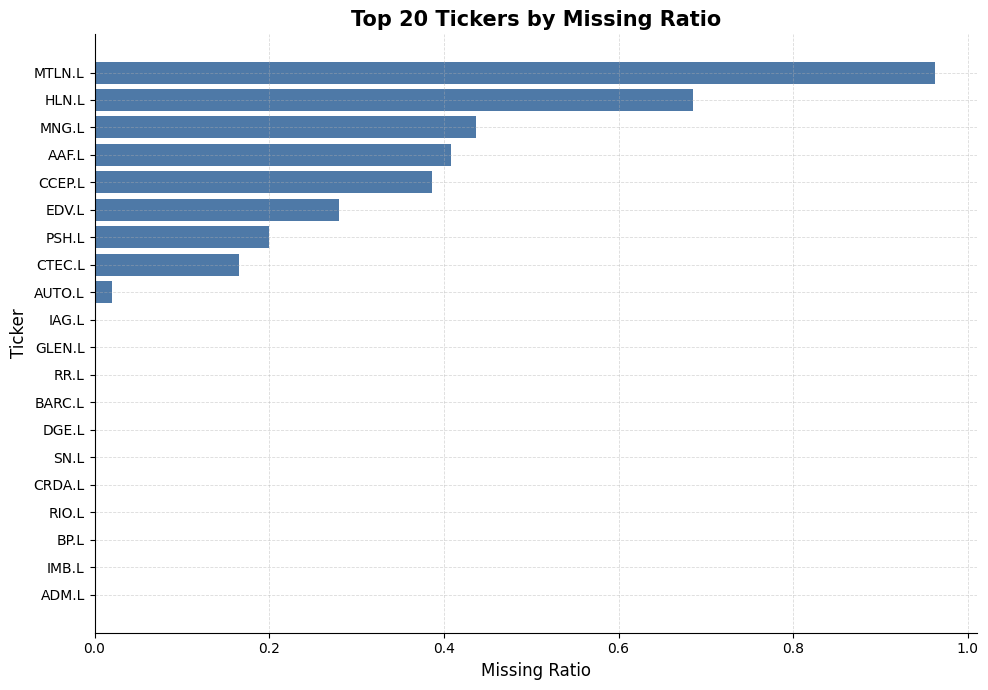

In [14]:
top_missing = missing_ratio.head(20).sort_values(ascending=True)

manual_fig_save = FIGURES_DIR / "top20_missing_ratio_bar.png"
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_missing.index, top_missing.values, color=AUX_COLORS["bar"])
ax.set_title("Top 20 Tickers by Missing Ratio", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Missing Ratio", fontsize=STYLE.label_size)
ax.set_ylabel("Ticker", fontsize=STYLE.label_size)
ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(manual_fig_save, dpi=STYLE.dpi, bbox_inches="tight")
plt.show()

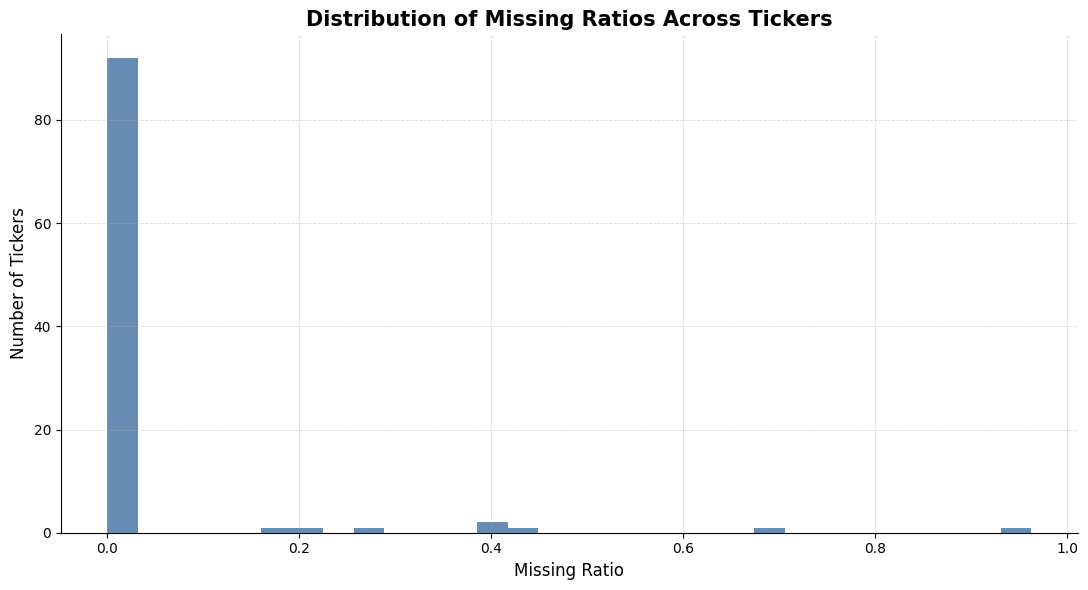

In [15]:
fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.hist(missing_ratio.values, bins=30, color=AUX_COLORS["hist"], alpha=STYLE.hist_alpha)
ax.set_title("Distribution of Missing Ratios Across Tickers", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Missing Ratio", fontsize=STYLE.label_size)
ax.set_ylabel("Number of Tickers", fontsize=STYLE.label_size)
ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

The missing-ratio analysis shows that most tickers have strong coverage, while a smaller group has substantial missingness.  
This type of missingness is largely structural rather than random, often caused by later listing dates or incomplete market history.

In the preprocessing pipeline, these issues are addressed by:

- removing tickers with excessive missingness
- filling only very small gaps conservatively
- dropping rows that still lack complete features after rolling calculations

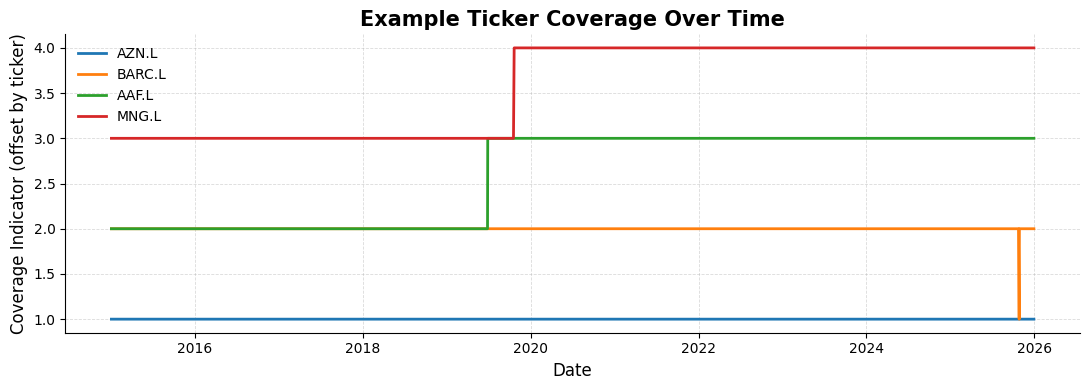

In [16]:
selected_tickers = ["AZN.L", "BARC.L", "AAF.L", "MNG.L"]
coverage = adj_close[selected_tickers].notna().astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
for i, ticker in enumerate(selected_tickers):
    ax.plot(coverage.index, coverage[ticker] + i, label=ticker, linewidth=2)

ax.set_title("Example Ticker Coverage Over Time", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Date", fontsize=STYLE.label_size)
ax.set_ylabel("Coverage Indicator (offset by ticker)", fontsize=STYLE.label_size)
ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.legend(frameon=False, fontsize=STYLE.legend_size, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Missing-value handling strategy

The preprocessing pipeline handles missingness in stages:

1. **Inspect raw missingness**
2. **Remove very poor-quality tickers**
3. **Fill only tiny gaps conservatively**
4. **Compute returns**
5. **Construct rolling features**
6. **Drop remaining incomplete rows before model fitting**

This approach avoids pretending that long missing stretches contain meaningful information.

In [17]:
policy_table = pd.DataFrame(
    {
        "stage": [
            "Raw prices",
            "High-missing tickers",
            "Tiny isolated gaps",
            "Rolling feature warm-up period",
            "Final ML dataset",
        ],
        "handling": [
            "Inspect missingness across tickers",
            "Remove if missingness is too high",
            "Fill conservatively only if gap is very small",
            "Accept early NaNs due to insufficient lookback history",
            "Drop incomplete rows with missing features/target",
        ],
    }
)
policy_table

,stage,handling
0,Raw prices,Inspect missingness across tickers
1,High-missing tickers,Remove if missingness is too high
2,Tiny isolated gaps,Fill conservatively only if gap is very small
3,Rolling feature warm-up period,Accept early NaNs due to insufficient lookback...
4,Final ML dataset,Drop incomplete rows with missing features/target


## 5. Raw price exploration

Before constructing returns, inspecta a few representative adjusted close price series.

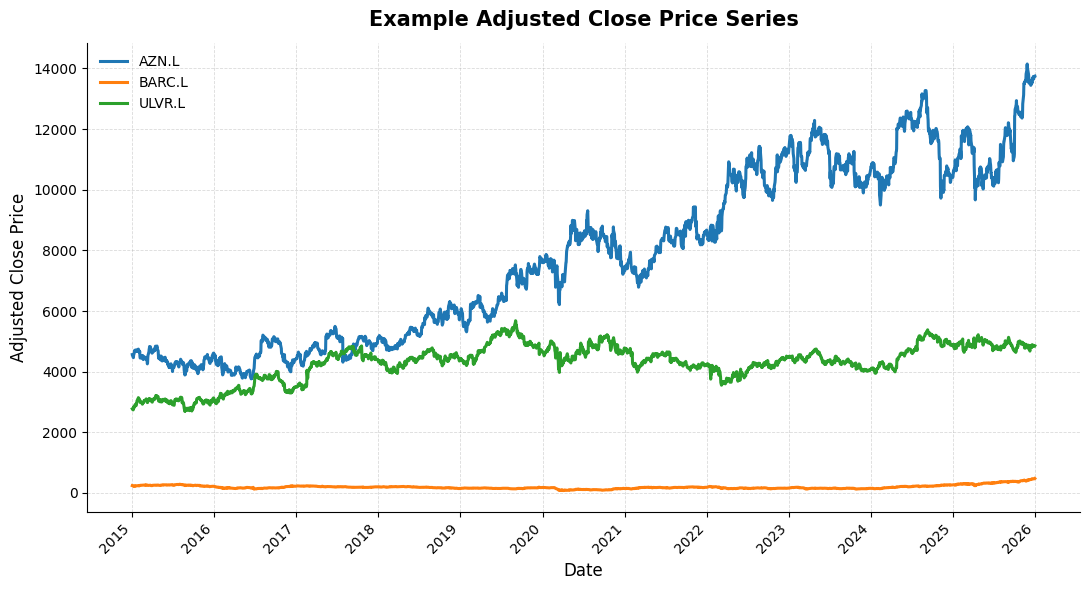

In [18]:
price_sample = adj_close[["AZN.L", "BARC.L", "ULVR.L"]].dropna(how="all")
plot_multi_series(
    series_map={col: price_sample[col].dropna() for col in price_sample.columns},
    title="Example Adjusted Close Price Series",
    ylabel="Adjusted Close Price",
    show=True,
)

## 6. Return construction

Returns are constructed from adjusted close prices.

- **Daily returns** are computed first
- **Monthly returns** are then compounded from the daily series
- The prediction target is the **next-month return**

This is preferable to working directly with raw prices, since returns are the economically meaningful quantity for forecasting and portfolio construction.

In [19]:
returns_paths = get_processed_returns_paths()

returns_daily_path = PROJECT_ROOT / returns_paths["daily"]
returns_monthly_path = PROJECT_ROOT / returns_paths["monthly"]
train_monthly_path = PROJECT_ROOT / returns_paths["train_monthly"]
test_monthly_path = PROJECT_ROOT / returns_paths["test_monthly"]

print("returns_daily_path:", returns_daily_path, returns_daily_path.exists())
print("returns_monthly_path:", returns_monthly_path, returns_monthly_path.exists())
print("train_monthly_path:", train_monthly_path, train_monthly_path.exists())
print("test_monthly_path:", test_monthly_path, test_monthly_path.exists())

returns_daily = pd.read_parquet(returns_daily_path)
returns_monthly = pd.read_parquet(returns_monthly_path)
train_monthly = pd.read_parquet(train_monthly_path)
test_monthly = pd.read_parquet(test_monthly_path)

returns_daily.index = pd.to_datetime(returns_daily.index)
returns_monthly.index = pd.to_datetime(returns_monthly.index)
train_monthly.index = pd.to_datetime(train_monthly.index)
test_monthly.index = pd.to_datetime(test_monthly.index)

returns_daily = returns_daily.sort_index()
returns_monthly = returns_monthly.sort_index()
train_monthly = train_monthly.sort_index()
test_monthly = test_monthly.sort_index()

returns_daily_path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\processed\returns\returns_daily.parquet True
returns_monthly_path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\processed\returns\returns_monthly.parquet True
train_monthly_path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\processed\returns\train_monthly_2015_2024.parquet True
test_monthly_path: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\data\processed\returns\test_monthly_2025.parquet True


In [20]:
returns_overview = pd.DataFrame(
    {
        "dataset": ["Daily Returns", "Monthly Returns", "Train Monthly", "Test Monthly"],
        "shape": [
            returns_daily.shape,
            returns_monthly.shape,
            train_monthly.shape,
            test_monthly.shape,
        ],
        "start_date": [
            returns_daily.index.min(),
            returns_monthly.index.min(),
            train_monthly.index.min(),
            test_monthly.index.min(),
        ],
        "end_date": [
            returns_daily.index.max(),
            returns_monthly.index.max(),
            train_monthly.index.max(),
            test_monthly.index.max(),
        ],
    }
)
returns_overview

,dataset,shape,start_date,end_date
0,Daily Returns,"(2778, 100)",2015-01-02,2025-12-30
1,Monthly Returns,"(132, 100)",2015-01-31,2025-12-31
2,Train Monthly,"(120, 100)",2015-01-31,2024-12-31
3,Test Monthly,"(12, 100)",2025-01-31,2025-12-31


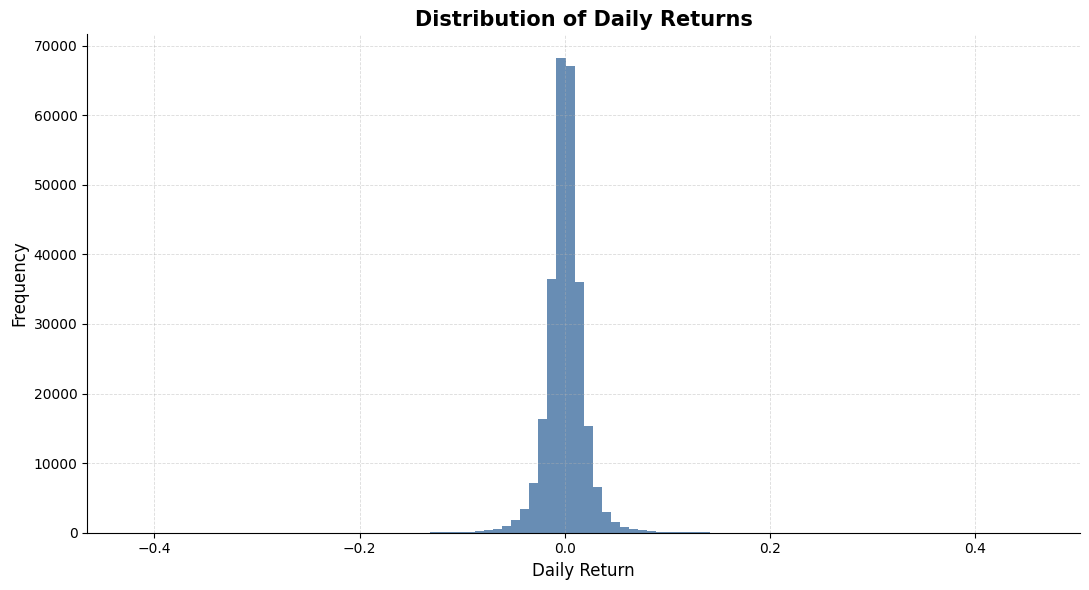

In [21]:
daily_values = returns_daily.to_numpy().ravel()
daily_values = daily_values[~np.isnan(daily_values)]

fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.hist(daily_values, bins=100, color=AUX_COLORS["hist"], alpha=STYLE.hist_alpha)
ax.set_title("Distribution of Daily Returns", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Daily Return", fontsize=STYLE.label_size)
ax.set_ylabel("Frequency", fontsize=STYLE.label_size)
ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

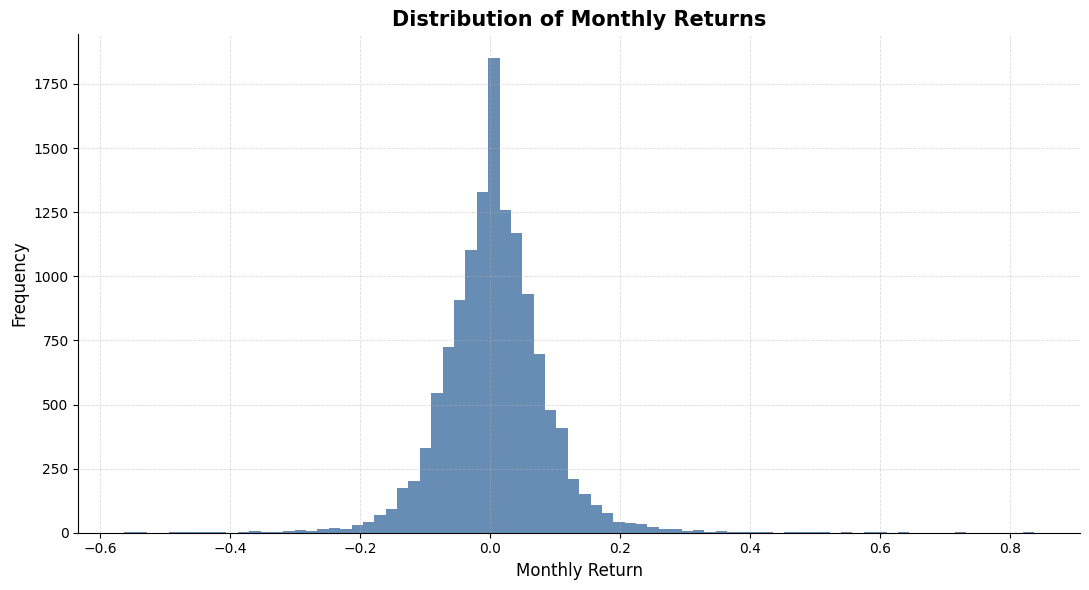

In [22]:
monthly_values = returns_monthly.to_numpy().ravel()
monthly_values = monthly_values[~np.isnan(monthly_values)]

fig, ax = plt.subplots(figsize=STYLE.figsize)
ax.hist(monthly_values, bins=80, color=AUX_COLORS["hist"], alpha=STYLE.hist_alpha)
ax.set_title("Distribution of Monthly Returns", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Monthly Return", fontsize=STYLE.label_size)
ax.set_ylabel("Frequency", fontsize=STYLE.label_size)
ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [23]:
return_summary = pd.DataFrame(
    {
        "Daily Returns": pd.Series(daily_values).describe(),
        "Monthly Returns": pd.Series(monthly_values).describe(),
    }
)
return_summary

,Daily Returns,Monthly Returns
count,267824.000000,13200.000000
mean,0.000384,0.007286
std,0.019009,0.079334
min,-0.421642,-0.563037
25%,-0.008249,-0.035854
50%,0.000439,0.003797
75%,0.009143,0.049649
max,0.458206,0.838235


## 7. Train/test split

The data is split strictly by time:

- **Train:** 2015–2024
- **Test:** 2025

This is critical for realistic forecasting.  
A random split would leak future information into the training set and overstate model performance.

In [24]:
split_summary = pd.DataFrame(
    {
        "split": ["Train", "Test"],
        "start_date": [train_monthly.index.min(), test_monthly.index.min()],
        "end_date": [train_monthly.index.max(), test_monthly.index.max()],
        "n_months": [train_monthly.shape[0], test_monthly.shape[0]],
        "n_tickers": [train_monthly.shape[1], test_monthly.shape[1]],
    }
)
split_summary

,split,start_date,end_date,n_months,n_tickers
0,Train,2015-01-31,2024-12-31,120,100
1,Test,2025-01-31,2025-12-31,12,100


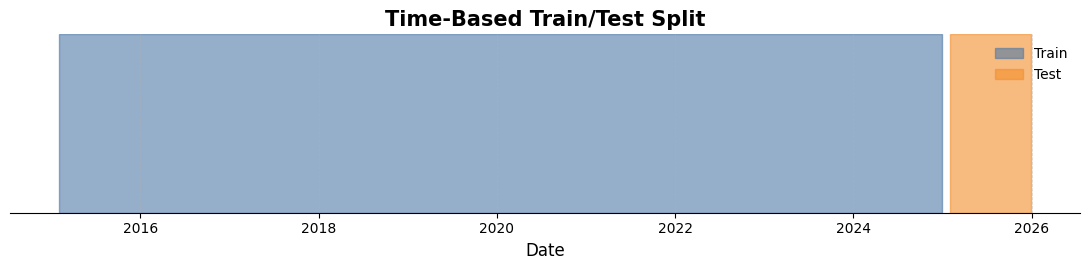

In [25]:
fig, ax = plt.subplots(figsize=(11, 2.8))

ax.axvspan(train_monthly.index.min(), train_monthly.index.max(), alpha=0.6, color="#4E79A7", label="Train")
ax.axvspan(test_monthly.index.min(), test_monthly.index.max(), alpha=0.6, color="#F28E2B", label="Test")

ax.set_title("Time-Based Train/Test Split", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Date", fontsize=STYLE.label_size)
ax.set_yticks([])
ax.grid(True, axis="x", linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="x", labelsize=STYLE.tick_size)
ax.legend(frameon=False, fontsize=STYLE.legend_size, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

In [26]:
final_summary = pd.DataFrame(
    {
        "item": [
            "Raw adjusted close shape",
            "Raw OHLCV shape",
            "Adjusted close date range",
            "OHLCV date range",
            "Daily returns shape",
            "Monthly returns shape",
            "Train monthly shape",
            "Test monthly shape",
            "Number of configured tickers",
            "Usable adjusted close tickers",
        ],
        "value": [
            adj_close.shape,
            ohlcv.shape,
            f"{adj_close.index.min().date()} -> {adj_close.index.max().date()}",
            f"{ohlcv.index.min().date()} -> {ohlcv.index.max().date()}",
            returns_daily.shape,
            returns_monthly.shape,
            train_monthly.shape,
            test_monthly.shape,
            len(config.TICKERS),
            adj_close.shape[1],
        ],
    }
)
final_summary

,item,value
0,Raw adjusted close shape,"(2778, 100)"
1,Raw OHLCV shape,"(2778, 600)"
2,Adjusted close date range,2015-01-02 -> 2025-12-30
3,OHLCV date range,2015-01-02 -> 2025-12-30
4,Daily returns shape,"(2778, 100)"
5,Monthly returns shape,"(132, 100)"
6,Train monthly shape,"(120, 100)"
7,Test monthly shape,"(12, 100)"
8,Number of configured tickers,100
9,Usable adjusted close tickers,100


## 8. Key findings from data download and preprocessing

The exploratory analysis shows the following:

- most tickers have strong historical coverage, though a subset has substantial missingness
- missingness is partly structural, reflecting listing history and data availability
- adjusted close prices provide a clean basis for return construction
- OHLCV data is available for extending the feature space
- daily and monthly return distributions are noisy, confirming that next-month return prediction is a difficult task
- the time-based train/test split provides a realistic evaluation framework and avoids information leakage

This preprocessing foundation supports the later stages of feature engineering, model training, and portfolio evaluation.

In [27]:
save_table(config_summary, "config_summary.csv", index=False)
save_table(raw_overview, "raw_overview.csv", index=False)
save_table(policy_table, "missing_policy.csv", index=False)
save_table(returns_overview, "returns_overview.csv", index=False)
save_table(split_summary, "split_summary.csv", index=False)
save_table(final_summary, "final_summary.csv", index=False)
save_table(missing_ratio.rename("missing_ratio").reset_index(), "missing_ratio_by_ticker.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\config_summary.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\raw_overview.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\missing_policy.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\returns_overview.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\split_summary.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\final_summary.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook01\missing_ratio_by_ticker.csv
